In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("data/spam.csv", encoding="latin-1")

In [3]:
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

In [4]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [6]:
df["label"].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [7]:
print("Spam messages:")
df[df["label"] == "spam"].head()

Spam messages:


,label,message
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
5,spam,FreeMsg Hey there darling it's been 3 week's n...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...
11,spam,"SIX chances to win CASH! From 100 to 20,000 po..."


In [8]:
print("Ham messages:")
df[df["label"] == "ham"].head()

Ham messages:


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
6,ham,Even my brother is not like to speak with me. ...


In [9]:
df["length"] = df["message"].apply(len)

In [10]:
df.head()

,label,message,length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [11]:
df["length"].describe()

count    5572.000000
mean       80.118808
std        59.690841
min         2.000000
25%        36.000000
50%        61.000000
75%       121.000000
max       910.000000
Name: length, dtype: float64

In [12]:
df.groupby("label")["length"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4825.0,71.023627,58.016023,2.0,33.0,52.0,92.0,910.0
spam,747.0,138.866131,29.183082,13.0,132.5,149.0,157.0,224.0


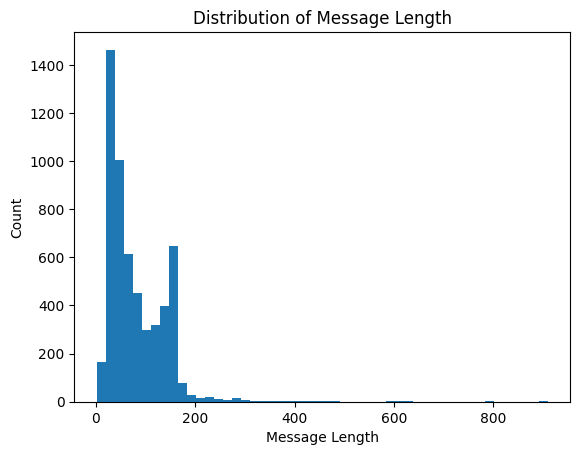

In [13]:
plt.hist(df["length"], bins=50)
plt.xlabel("Message Length")
plt.ylabel("Count")
plt.title("Distribution of Message Length")
plt.show()

In [14]:
import nltk

nltk.download("stopwords")
nltk.download("punkt")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\and98\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\and98\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [15]:
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [16]:
message = "Congratulations! You have won a FREE prize."

tokens = word_tokenize(message)

print(tokens)

['Congratulations', '!', 'You', 'have', 'won', 'a', 'FREE', 'prize', '.']


In [17]:
import nltk
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\and98\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [18]:
message = "Congratulations! You have won a FREE prize."

tokens = word_tokenize(message)
print(tokens)

['Congratulations', '!', 'You', 'have', 'won', 'a', 'FREE', 'prize', '.']


In [19]:
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

def clean_text (text):
    text = text.lower()
    words = word_tokenize(text)
    words = [word for word in words if word not in string.punctuation]
    words = [word for word in words if word not in stopwords.words("english")]
    return words

In [20]:
message = "Congratulations! You have won a FREE prize."

print(clean_text(message))

['congratulations', 'free', 'prize']


In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [22]:
tfidf = TfidfVectorizer()

In [23]:
X = tfidf.fit_transform(df["message"])

In [24]:
print(type(X))

<class 'scipy.sparse._csr.csr_matrix'>


In [25]:
print(X.shape)

(5572, 8672)


In [26]:
df["label"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

In [27]:
df.head()

,label,message,length
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [28]:
y = df["label"]

In [29]:
from sklearn.model_selection import train_test_split

y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [30]:
print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (4457, 8672)
Testing: (1115, 8672)


In [31]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [32]:
y_pred = model.predict(X_test)

In [33]:
print(y_pred[:20])

[0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [34]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9614349775784753

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       966
           1       1.00      0.71      0.83       149

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.90      1115
weighted avg       0.96      0.96      0.96      1115


Confusion Matrix:
[[966   0]
 [ 43 106]]


In [35]:
print(confusion_matrix(y_test, y_pred))

[[966   0]
 [ 43 106]]


In [36]:
from sklearn.model_selection import train_test_split

X = df["message"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [38]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

In [39]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9605381165919282
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       966
           1       1.00      0.70      0.83       149

    accuracy                           0.96      1115
   macro avg       0.98      0.85      0.90      1115
weighted avg       0.96      0.96      0.96      1115

[[966   0]
 [ 44 105]]


In [40]:
def predict_message(message):
    message_tfidf = tfidf.transform([message])
    prediction = model.predict(message_tfidf)[0]

    if prediction == 1:
        return "SPAM"
    else:
        return "HAM"

In [41]:
print(predict_message("Congratulations! You won a free iPhone. Claim your prize now!"))

print(predict_message("Hey bro, are you coming to class tomorrow?"))

SPAM
HAM


In [42]:
print(predict_message("Hey, did you know you have rights, the constitution says you do and so do I, BETTER CALL SAUL"))

HAM


In [43]:
print(predict_message(
    "URGENT! You have won $1000 cash. Click now to claim your free prize!"
))

SPAM


In [44]:
print(predict_message(
    "Hey bro, I won a free ticket yesterday, call me when you can"
))

HAM


In [45]:
tfidf_clean = TfidfVectorizer(
    tokenizer=clean_text,
    token_pattern=None
)

In [46]:
X_train_clean = tfidf_clean.fit_transform(X_train)
X_test_clean = tfidf_clean.transform(X_test)

In [47]:
print("Baseline:", X_train_tfidf.shape)
print("Cleaned:", X_train_clean.shape)

Baseline: (4457, 7701)
Cleaned: (4457, 8228)


In [48]:
model_clean = MultinomialNB()

model_clean.fit(X_train_clean, y_train)

y_pred_clean = model_clean.predict(X_test_clean)

In [49]:
print("CLEANED MODEL")

print("Accuracy:", accuracy_score(y_test, y_pred_clean))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_clean))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_clean))

CLEANED MODEL
Accuracy: 0.9623318385650225

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       966
           1       1.00      0.72      0.84       149

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115


Confusion Matrix:
[[966   0]
 [ 42 107]]


In [50]:
results = X_test.to_frame(name="message")

results["actual"] = y_test
results["predicted"] = y_pred_clean

missed_spam = results[
    (results["actual"] == 1) &
    (results["predicted"] == 0)
]

missed_spam.head(10)

,message,actual,predicted
3057,You are now unsubscribed all services. Get ton...,1,0
5,FreeMsg Hey there darling it's been 3 week's n...,1,0
1021,Guess what! Somebody you know secretly fancies...,1,0
3748,Dear Voucher Holder 2 claim your 1st class air...,1,0
855,Talk sexy!! Make new friends or fall in love i...,1,0
3139,sexy sexy cum and text me im wet and warm and ...,1,0
1662,Hi if ur lookin 4 saucy daytime fun wiv busty ...,1,0
3979,ringtoneking 84484,1,0
3358,Sorry I missed your call let's talk when you h...,1,0
3546,Rock yr chik. Get 100's of filthy films &XXX p...,1,0


In [51]:
for alpha in [1.0, 0.5, 0.1, 0.01]:

    test_model = MultinomialNB(alpha=alpha)
    test_model.fit(X_train_clean, y_train)

    predictions = test_model.predict(X_test_clean)

    print("Alpha:", alpha)
    print(classification_report(y_test, predictions))
    print(confusion_matrix(y_test, predictions))
    print("-" * 50)

Alpha: 1.0
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       966
           1       1.00      0.72      0.84       149

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115

[[966   0]
 [ 42 107]]
--------------------------------------------------
Alpha: 0.5
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       966
           1       1.00      0.80      0.89       149

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.94      1115
weighted avg       0.97      0.97      0.97      1115

[[966   0]
 [ 30 119]]
--------------------------------------------------
Alpha: 0.1
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       0.99      0.88      0.93       149

 

In [52]:
best_nb_model = MultinomialNB(alpha=0.1)
best_nb_model.fit(X_train_clean, y_train)

MultinomialNB(alpha=0.1)

In [53]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000
)

log_model.fit(X_train_clean, y_train)

LogisticRegression(max_iter=1000)

In [54]:
y_pred_log = log_model.predict(X_test_clean)

In [55]:
print("LOGISTIC REGRESSION")

print("Accuracy:", accuracy_score(y_test, y_pred_log))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

LOGISTIC REGRESSION
Accuracy: 0.9623318385650225

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       966
           1       0.98      0.73      0.84       149

    accuracy                           0.96      1115
   macro avg       0.97      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115


Confusion Matrix:
[[964   2]
 [ 40 109]]


In [56]:
def predict_spam(message):
    message_vector = tfidf_clean.transform([message])
    prediction = best_nb_model.predict(message_vector)[0]

    if prediction == 1:
        return "SPAM"
    else:
        return "HAM"

In [57]:
print(predict_spam(
    "URGENT! Congratulations, you have won a free £1000 cash prize. Call now to claim!"
))

print(predict_spam(
    "Hey bro, are you coming to class tomorrow?"
))

SPAM
HAM


In [58]:
import joblib

joblib.dump(tfidf_clean, "vectorizer.pkl")
joblib.dump(best_nb_model, "spam_model.pkl")

['spam_model.pkl']

In [59]:
loaded_vectorizer = joblib.load("vectorizer.pkl")
loaded_model = joblib.load("spam_model.pkl")

In [60]:
message = "URGENT! You have won a free cash prize. Claim now!"

message_vector = loaded_vectorizer.transform([message])
prediction = loaded_model.predict(message_vector)[0]

print("SPAM" if prediction == 1 else "HAM")

SPAM
